### Problem Statement

You are a data scientist / AI engineer working on a classification problem to predict the weather type based on various weather-related features. You have been provided with a dataset named **`"weather_classification_data.csv"`**, which includes several parameters affecting weather conditions. The dataset comprises the following columns:

- temperature: The temperature in degrees Celsius.
- humidity: The humidity percentage.
- wind_speed: The wind speed in kilometers per hour.
- precipitation (%): The precipitation percentage.
- cloud_cover: The cloud cover description.
- atmospheric_pressure: The atmospheric pressure in hPa.
- uv_index: The UV index.
- season: The season during which the data was recorded.
- visibility (km): The visibility in kilometers.
- location: The type of location where the data was recorded.
- weather_type: The target variable for classification, indicating the weather type (Rainy, Sunny, Cloudy, Snowy).
  
Your task is to use this dataset to build and evaluate machine learning models to predict the weather type based on the given parameters. You will perform data preprocessing, exploratory data analysis, and model training using Support Vector Machine (SVM) with different kernels.

Dataset credits: Nikhil Narayan (https://www.kaggle.com/datasets/nikhil7280/weather-type-classification)

**Import Necessary Libraries**

In [85]:
# Import Necessary Libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

### Task 1: Data Preparation and Exploration

1. Import the data from the `"weather_data.csv"` file and store it in a DataFrame.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to understand its structure.
4. Check for any missing values in the dataset and handle them appropriately.
5. Visualize the distribution of key features using appropriate charts:
    - Visualize `season` using a pie chart.
    - Visualize `temperature, humidity, and wind_speed` using histograms.
    - Visualize `precipitation (%)` using a box plot.

In [86]:
# Step 1: Import the data from the "weather_data.csv" file
df=pd.read_csv("weather_classification_data.csv")

# Step 2: Display the number of rows and columns in the dataset
df.shape

# Step 3: Display the first few rows of the dataset to understand its structure.
df.head()

,temperature,humidity,wind_speed,precipitation (%),cloud_cover,atmospheric_pressure,uv_index,season,visibility (km),location,weather_type
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy


In [87]:
df['season'].unique()

array(['Winter', 'Spring', 'Summer', 'Autumn'], dtype=object)

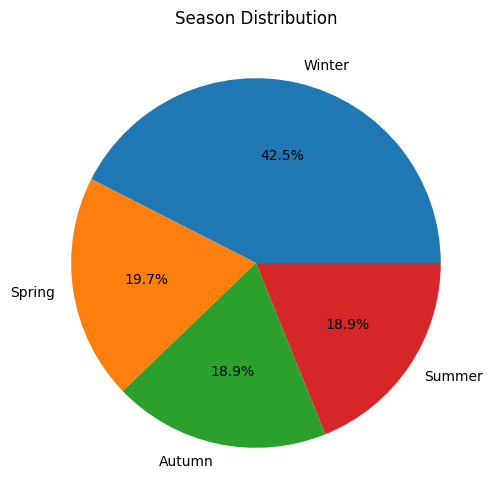

In [88]:
# Step 4: Visualize the distribution of key features
counts = df['season'].value_counts()

# Plot pie chart
counts.plot.pie(autopct='%1.1f%%', figsize=(6,6))

plt.ylabel('')  # removes default ylabel
plt.title('Season Distribution')
plt.show()

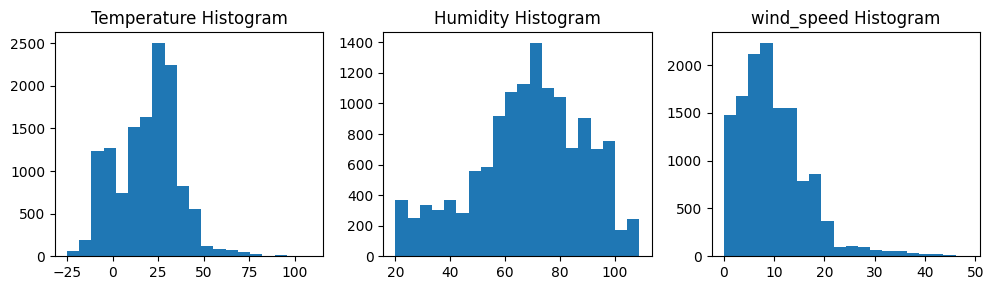

In [89]:
# Visualize temperature, humidity, and wind_speed using histograms
plt.figure(figsize=(10,3))

# Plot 1
plt.subplot(1, 3, 1)  # (rows, cols, position)
plt.hist(df['temperature'], bins=20)
plt.title('Temperature Histogram')

# Plot 2
plt.subplot(1, 3, 2)
plt.hist(df['humidity'], bins=20)
plt.title('Humidity Histogram')

plt.subplot(1, 3, 3)
plt.hist(df['wind_speed'], bins=20)
plt.title('wind_speed Histogram')

plt.tight_layout()
plt.show()


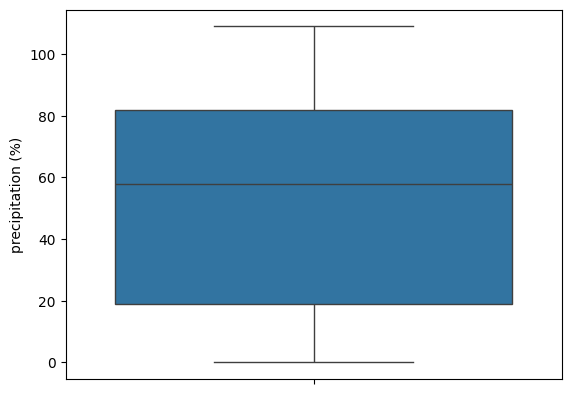

In [90]:
# Visualize precipitation (%) using a box plot
sns.boxplot(df['precipitation (%)'])
plt.show()

### Task 2: Data Transformation

1. Encode cloud_cover, location and season using one-hot encoding.
2. Scale the numerical features (temperature, humidity, wind_speed, precipitation (%), atmospheric_pressure, uv_index, visibility (km)) using StandardScaler.
3. Display the first few rows of the updated dataset.

In [91]:
# Step 1: Encode cloud_cover, location and season using one-hot encoding.

encoded_df1 = pd.get_dummies(df, columns=['cloud_cover'], drop_first=True)
encoded_df2 = pd.get_dummies(df, columns=['location'], drop_first=True)
encoded_df3 = pd.get_dummies(df, columns=['season'], drop_first=True)
encoded_df4 = pd.get_dummies(df, columns=['cloud_cover','location','season'],drop_first=True)

In [92]:
encoded_df4

,temperature,humidity,wind_speed,precipitation (%),atmospheric_pressure,uv_index,visibility (km),weather_type,cloud_cover_cloudy,cloud_cover_overcast,cloud_cover_partly cloudy,location_inland,location_mountain,season_Spring,season_Summer,season_Winter
0,14,73,9.5,82,1010.82,2,3.5,Rainy,False,False,True,True,False,False,False,True
1,39,96,8.5,71,1011.43,7,10.0,Cloudy,False,False,True,True,False,True,False,False
2,30,64,7.0,16,1018.72,5,5.5,Sunny,False,False,False,False,True,True,False,False
3,38,83,1.5,82,1026.25,7,1.0,Sunny,False,False,False,False,False,True,False,False
4,27,74,17.0,66,990.67,1,2.5,Rainy,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13195,10,74,14.5,71,1003.15,1,1.0,Rainy,False,True,False,False,True,False,True,False
13196,-1,76,3.5,23,1067.23,1,6.0,Snowy,True,False,False,False,False,False,False,True
13197,30,77,5.5,28,1012.69,3,9.0,Cloudy,False,True,False,False,False,False,False,False
13198,3,76,10.0,94,984.27,0,2.0,Snowy,False,True,False,True,False,False,False,True


In [93]:
# Step 2: Scale the numerical features
num_features=['temperature', 'humidity', 'wind_speed', 'precipitation (%)', 'atmospheric_pressure', 'uv_index', 'visibility (km)']
scaler=StandardScaler()
encoded_df4[num_features]=scaler.fit_transform(df[num_features])

In [94]:
df['weather_type'].unique()

array(['Rainy', 'Cloudy', 'Sunny', 'Snowy'], dtype=object)

In [95]:
encoded_df4['weather_type']=encoded_df4['weather_type'].replace(['Rainy', 'Cloudy', 'Sunny', 'Snowy'],[0,1,2,3])

In [96]:
# Step3: Display the first few rows of the updated dataset.
encoded_df4.head()


,temperature,humidity,wind_speed,precipitation (%),atmospheric_pressure,uv_index,visibility (km),weather_type,cloud_cover_cloudy,cloud_cover_overcast,cloud_cover_partly cloudy,location_inland,location_mountain,season_Spring,season_Summer,season_Winter
0,-0.294931,0.212404,-0.048086,0.887629,0.134203,-0.520104,-0.582231,0,False,False,True,True,False,False,False,True
1,1.143035,1.351385,-0.192836,0.543291,0.150602,0.776424,1.345768,1,False,False,True,True,False,True,False,False
2,0.625367,-0.233285,-0.409962,-1.178401,0.346579,0.257813,0.010999,2,False,False,False,False,True,True,False,False
3,1.085516,0.707613,-1.206089,0.887629,0.549008,0.776424,-1.323769,2,False,False,False,False,False,True,False,False
4,0.452811,0.261924,1.037543,0.386773,-0.407490,-0.779410,-0.878846,0,False,True,False,False,True,False,False,True


### Task 3: Model Training Using SVM with Linear Kernel

1. Select the features and the target variable for modeling.
2. Split the data into training and test sets with a test size of 30%.
3. Initialize and train an SVM model with a linear kernel using the training data.
4. Print the model's accuracy score on test data.
5. Evaluate the model using a classification report and confusion matrix.

In [97]:
# Step 1: Select features and target variable
X=encoded_df4.drop(columns='weather_type', axis=1)
y=encoded_df4['weather_type']
# Step 2: Split the data
X_train, X_test,y_train, y_test=train_test_split(X,y,test_size=.3,random_state=42)

In [100]:
# Step 3: Train SVM with linear kernel
svm=SVC(kernel='linear')
svm.fit(X_train,y_train)
prediction=svm.predict(X_test)
# Step 4: Print accuracy score
svm.score(X_test, y_test)


0.88510101010101

              precision    recall  f1-score   support

           0       0.87      0.87      0.87       982
           1       0.86      0.84      0.85       955
           2       0.92      0.88      0.90       990
           3       0.88      0.94      0.91      1033

    accuracy                           0.89      3960
   macro avg       0.89      0.88      0.88      3960
weighted avg       0.89      0.89      0.88      3960



<Axes: >

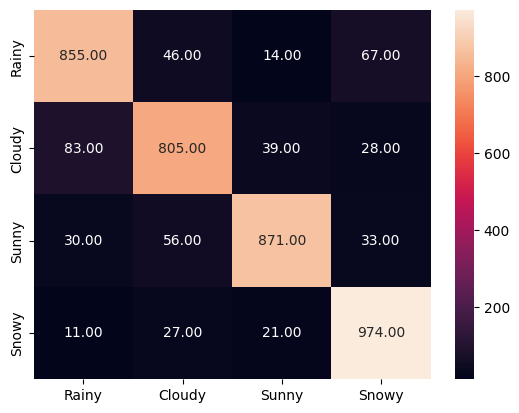

In [105]:
# Step 5: Evaluate the model


#classification report
report=classification_report(y_test,prediction)
print(report)

#confusion matrix
cm=confusion_matrix(y_test,prediction)
sns.heatmap(cm,annot=True,xticklabels=df['weather_type'].unique(),
    yticklabels=df['weather_type'].unique(),fmt=".2f")

### Task 4: Model Training Using SVM with RBF Kernel

1. Initialize and train an SVM model with an RBF kernel using the training data.
2. Print the model's accuracy score on test data.
3. Evaluate the model using a classification report and confusion matrix.

              precision    recall  f1-score   support

           0       0.88      0.91      0.90       982
           1       0.88      0.87      0.87       955
           2       0.93      0.89      0.91       990
           3       0.92      0.94      0.93      1033

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



<Axes: >

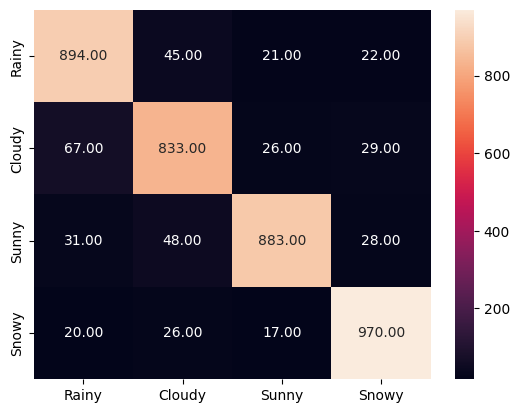

In [109]:
# Step 1: Train SVM with RBF kernel
pipeline=Pipeline([
   ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
]
)


# Step 2: Print accuracy score
pipeline.fit(X_train,y_train)



# Step 3: Evaluate the model

#classification report
prediction2=pipeline.predict(X_test)
report2=classification_report(y_test,prediction2)
print(report2)

#confusion matrix
cm2=confusion_matrix(y_test,prediction2)
sns.heatmap(cm2,annot=True,xticklabels=df['weather_type'].unique(),
    yticklabels=df['weather_type'].unique(),fmt=".2f")


### Task 5: Experiment with Hyperparameters in SVM

1. Train an SVM model with an RBF kernel and the following hyperparameters:
    - C=0.5
    - gamma='auto'
    - kernel='rbf'
    - degree=2
      
Learn about these parameters here: [SVC Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

--------------------------------------------------------------------------------------------------------------------------------------------------------

2. Print the model's accuracy score on test data.
3. Evaluate the model using a classification report and confusion matrix.

0.9
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       982
           1       0.88      0.87      0.87       955
           2       0.93      0.89      0.91       990
           3       0.92      0.94      0.93      1033

    accuracy                           0.90      3960
   macro avg       0.90      0.90      0.90      3960
weighted avg       0.90      0.90      0.90      3960



<Axes: >

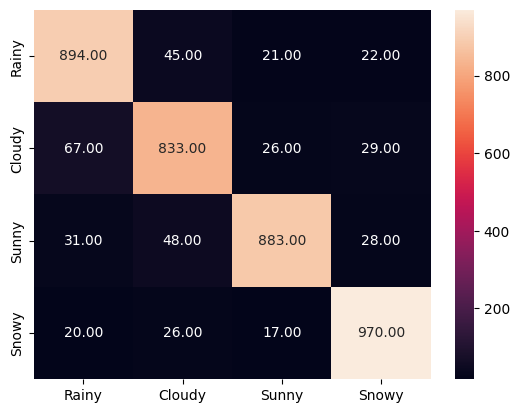

In [114]:
# Step 1: Train the SVM model with specified hyperparameters
pipeline2=Pipeline([
   ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf',C=.5,gamma='auto',degree=2))
]
)
pipeline2.fit(X_train, y_train)


# Step 2: Print the model's accuracy score
s=pipeline2.score(X_test,y_test)
print(s)

# Step 3: Make predictions on the test set
prediction3=pipeline.predict(X_test)


# Step 4: Evaluate the model using a classification report and confusion matrix
report3=classification_report(y_test,prediction3)
cm3=confusion_matrix(y_test,prediction3)


#classification report
print(report3)


#confusion matrix
sns.heatmap(cm3,annot=True,xticklabels=df['weather_type'].unique(),
    yticklabels=df['weather_type'].unique(),fmt=".2f")
